# Quick start

This guide demonstrates a minimal working example of the `qiskit-addon-obp` package. We use operator backpropagation (OBP) to reduce the depth of a quantum circuit by absorbing trailing gates into the observable.

An expectation value $\langle O \rangle = \langle \psi | U^\dagger O U | \psi \rangle$ is unchanged if we peel a trailing block of gates off the circuit $U$ and conjugate the observable by it classically. OBP applies this repeatedly, evaluating part of the circuit classically so that only a shallower circuit runs on hardware. The price is that each absorbed gate can expand the observable into more Pauli terms, so the depth saved must be weighed against the growth of the observable.

To see examples of how to build realistic workflows with this tool and execute on quantum hardware, check out the tutorials on the IBM Quantum Platform ([OBP Tutorial](https://quantum.cloud.ibm.com/docs/en/tutorials/operator-back-propagation)).

## Prepare inputs for OBP

OBP takes as input a list of circuit slices and an observable. It backpropagates slices one at a time from the end of the circuit into the observable, reducing circuit depth at the cost of additional Pauli terms in the observable. Here we generate a time-evolution circuit for a 10-qubit Heisenberg model and slice it by gate type.

Below we draw the original circuit, then the same circuit recombined with barriers marking the slice boundaries — each slice is a unit that can be absorbed into the observable in a single backpropagation step.

In [ ]:
import numpy as np
from qiskit.quantum_info import SparsePauliOp
from qiskit.synthesis import LieTrotter
from qiskit.transpiler import CouplingMap
from qiskit_addon_utils.problem_generators import (
    generate_time_evolution_circuit,
    generate_xyz_hamiltonian,
)
from qiskit_addon_utils.slicing import combine_slices, slice_by_gate_types

# Generate a circuit to reduce
coupling_map = CouplingMap.from_heavy_hex(3, bidirectional=False)
reduced_coupling_map = coupling_map.reduce([0, 13, 1, 14, 10, 16, 5, 12, 8, 18])

hamiltonian = generate_xyz_hamiltonian(
    reduced_coupling_map,
    coupling_constants=(np.pi / 8, np.pi / 4, np.pi / 2),
    ext_magnetic_field=(np.pi / 3, np.pi / 6, np.pi / 9),
)

circuit = generate_time_evolution_circuit(
    hamiltonian,
    time=0.2,
    synthesis=LieTrotter(reps=2),
)

# Slice the circuit and define an observable
slices = slice_by_gate_types(circuit)
observable = SparsePauliOp("IIIIIIIIIZ")

print(f"Original circuit depth: {circuit.depth()}")
print(f"Number of slices: {len(slices)}")
print(f"Observable terms: {len(observable)}")

In [ ]:
# Recombine the slices with barriers to make the slice boundaries visible
sliced_circuit = combine_slices(slices, include_barriers=True)

print("Original circuit:")
display(circuit.draw("mpl", scale=0.6, fold=-1))
print("Sliced circuit (recombined with barriers for visualization)")
sliced_circuit.draw("mpl", scale=0.6, fold=-1)

## Reduce circuit depth with OBP

We call `backpropagate` to absorb slices into the observable. The function returns the expanded observable, the circuit slices which were not propagated through, and metadata about the procedure.

Left unchecked, the observable can grow toward $2^n$ Pauli terms. The `operator_budget` caps this growth — here we allow at most 8 qubit-wise commuting groups, which roughly sets the number of shots required to evaluate the observable on the QPU. Backpropagation halts as soon as absorbing the next slice would exceed the budget, which is exactly what happens below: only 7 of the 18 slices are absorbed before the observable fills all 8 commuting groups and the procedure stops.

To push deeper into the circuit, the `truncation_error_budget` keyword argument to ``backpropagate`` can be used to drop small-coefficient Pauli terms from the observable as it grows. This dampens the growth of the observable in exchange for some error proportional to the magnitude of the Pauli terms being truncated. The two budgets are complementary and may be used together: `operator_budget` controls the *size* of the observable, while `truncation_error_budget` controls the *error* incurred by discarding terms.

In [ ]:
from qiskit_addon_obp import backpropagate
from qiskit_addon_obp.utils.simplify import OperatorBudget

max_qwc_groups = 8
bp_obs, remaining_slices, metadata = backpropagate(
    observable, slices, operator_budget=OperatorBudget(max_qwc_groups=max_qwc_groups)
)

reduced_circuit = combine_slices(remaining_slices)
num_groups = len(bp_obs.group_commuting(qubit_wise=True))

print(f"Backpropagated {metadata.num_backpropagated_slices} of {len(slices)} slices.")
print(f"Reduced circuit depth: {reduced_circuit.depth()} (was {circuit.depth()})")
print(f"Observable grew from {len(observable)} to {len(bp_obs)} Pauli terms.")
print(f"Filled {num_groups} of {max_qwc_groups} commuting groups, exhausting the budget.")

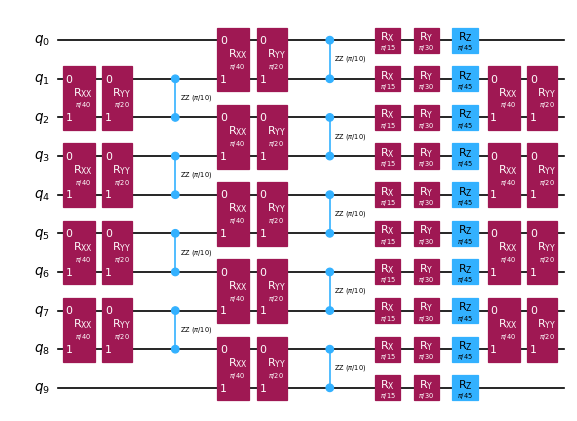

In [4]:
reduced_circuit.draw("mpl", scale=0.6, fold=-1)